# Analisis Regresi Linear Berganda
## Faktor-Faktor yang Mempengaruhi Harga Laptop di Pasar E-Commerce

---

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Styling
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid")
print("✅ Library berhasil diimport")

✅ Library berhasil diimport


---
## 2. Dataset Besar — Kaggle (1.275 data)
> Sumber: [Kaggle — Laptop Price Dataset](https://www.kaggle.com/)  
> Jumlah data: 1.275 baris | 15 kolom  
> Variabel Y: **Price (Euro)**

In [19]:
from google.colab import files
uploaded = files.upload()

Saving laptop_price - dataset.csv to laptop_price - dataset.csv


In [26]:
df_besar = pd.read_csv("laptop_price - dataset.csv", sep=";", encoding="latin-1")
print(f"Jumlah baris  : {len(df_besar)}")
print(f"Jumlah kolom  : {len(df_besar.columns)}")
print(f"Missing values: {df_besar.isnull().sum().sum()}")
df_besar.head()

Jumlah baris  : 1275
Jumlah kolom  : 15
Missing values: 0


,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


### 2.1 Eksplorasi Data

In [27]:
print("=== INFO DATASET ===")
df_besar.info()
print()
print("=== STATISTIK DESKRIPTIF ===")
df_besar.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1275 non-null   object 
 1   Product              1275 non-null   object 
 2   TypeName             1275 non-null   object 
 3   Inches               1275 non-null   float64
 4   ScreenResolution     1275 non-null   object 
 5   CPU_Company          1275 non-null   object 
 6   CPU_Type             1275 non-null   object 
 7   CPU_Frequency (GHz)  1275 non-null   float64
 8   RAM (GB)             1275 non-null   int64  
 9   Memory               1275 non-null   object 
 10  GPU_Company          1275 non-null   object 
 11  GPU_Type             1275 non-null   object 
 12  OpSys                1275 non-null   object 
 13  Weight (kg)          1275 non-null   float64
 14  Price (Euro)         1275 non-null   float64
dtypes: float64(4), in

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,2.302980,8.440784,2.040525,1134.969059
std,1.429470,0.503846,5.097809,0.669196,700.752504
min,10.100000,0.900000,2.000000,0.690000,174.000000
25%,14.000000,2.000000,4.000000,1.500000,609.000000
50%,15.600000,2.500000,8.000000,2.040000,989.000000
75%,15.600000,2.700000,8.000000,2.310000,1496.500000
max,18.400000,3.600000,64.000000,4.700000,6099.000000


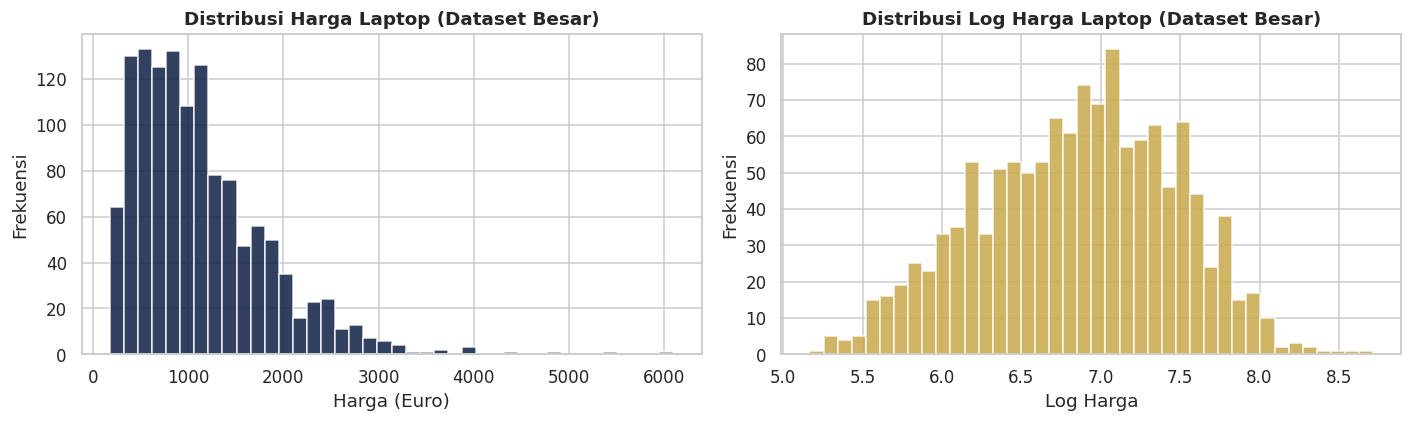

In [28]:
# Distribusi harga laptop
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_besar["Price (Euro)"], bins=40, color="#0F2044", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribusi Harga Laptop (Dataset Besar)", fontweight="bold")
axes[0].set_xlabel("Harga (Euro)")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(np.log1p(df_besar["Price (Euro)"]), bins=40, color="#C9A84C", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribusi Log Harga Laptop (Dataset Besar)", fontweight="bold")
axes[1].set_xlabel("Log Harga")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

### 2.2 Preprocessing Data
Kolom kategorikal (teks) perlu diubah ke angka menggunakan **Label Encoding** agar bisa diproses oleh model regresi.

In [30]:
df_b = df_besar.copy()

fitur_numerik  = ["Inches", "CPU_Frequency (GHz)", "RAM (GB)", "Weight (kg)"]
fitur_kategori = ["Company", "TypeName", "CPU_Company", "GPU_Company", "OpSys"]
target         = "Price (Euro)"

le = LabelEncoder()
for col in fitur_kategori:
    df_b[col + "_enc"] = le.fit_transform(df_b[col])

fitur_enc = fitur_numerik + [c + "_enc" for c in fitur_kategori]

X_b = df_b[fitur_enc]
y_b = df_b[target]

print("Fitur yang digunakan:")
for f in fitur_enc:
    print(f"  - {f}")
print(f"Total fitur (parameter X): {len(fitur_enc)}")

Fitur yang digunakan:
  - Inches
  - CPU_Frequency (GHz)
  - RAM (GB)
  - Weight (kg)
  - Company_enc
  - TypeName_enc
  - CPU_Company_enc
  - GPU_Company_enc
  - OpSys_enc
Total fitur (parameter X): 9


### 2.3 Model Regresi Linear Berganda

In [31]:
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

model_besar = LinearRegression()
model_besar.fit(X_b_train, y_b_train)

y_b_pred = model_besar.predict(X_b_test)

r2_b  = r2_score(y_b_test, y_b_pred)
mse_b = mean_squared_error(y_b_test, y_b_pred)
mae_b = mean_absolute_error(y_b_test, y_b_pred)
rmse_b = np.sqrt(mse_b)

print("=== HASIL EVALUASI MODEL (Dataset Besar) ===")
print(f"R² Score  : {r2_b:.4f}  →  model menjelaskan {r2_b*100:.1f}% variasi harga")
print(f"MAE       : {mae_b:.2f} Euro")
print(f"RMSE      : {rmse_b:.2f} Euro")

=== HASIL EVALUASI MODEL (Dataset Besar) ===
R² Score  : 0.6697  →  model menjelaskan 67.0% variasi harga
MAE       : 293.80 Euro
RMSE      : 404.88 Euro


In [32]:
koef_b = pd.DataFrame({
    "Parameter (X)": fitur_enc,
    "Koefisien"    : model_besar.coef_
}).sort_values("Koefisien", ascending=False).reset_index(drop=True)

print(f"Intercept (a) : {model_besar.intercept_:.4f}")
print()
print("Koefisien tiap parameter:")
print(koef_b.to_string(index=False))

Intercept (a) : 29.1531

Koefisien tiap parameter:
      Parameter (X)  Koefisien
    CPU_Company_enc 338.377746
CPU_Frequency (GHz) 267.699685
          OpSys_enc 109.394945
           RAM (GB)  87.905265
        Weight (kg)  77.316899
    GPU_Company_enc  49.702777
       TypeName_enc  32.496011
        Company_enc   7.318758
             Inches -99.001757


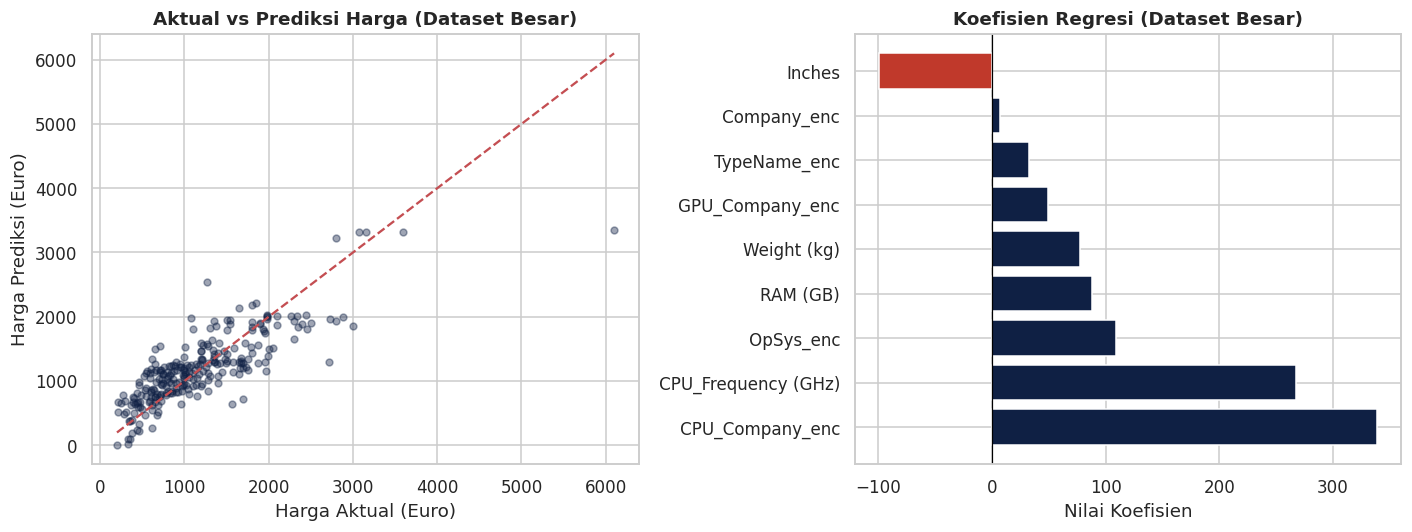

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_b_test, y_b_pred, alpha=0.4, color="#0F2044", s=20)
axes[0].plot([y_b_test.min(), y_b_test.max()],
             [y_b_test.min(), y_b_test.max()], "r--", lw=1.5)
axes[0].set_title("Aktual vs Prediksi Harga (Dataset Besar)", fontweight="bold")
axes[0].set_xlabel("Harga Aktual (Euro)")
axes[0].set_ylabel("Harga Prediksi (Euro)")

colors = ["#0F2044" if c >= 0 else "#C0392B" for c in koef_b["Koefisien"]]
axes[1].barh(koef_b["Parameter (X)"], koef_b["Koefisien"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Koefisien Regresi (Dataset Besar)", fontweight="bold")
axes[1].set_xlabel("Nilai Koefisien")

plt.tight_layout()
plt.show()

---
## 3. Dataset Kecil — Survey Mandiri (30 data)
> Sumber: Survey mandiri dari Tokopedia/Shopee (2025)  
> Jumlah data: 30 baris | 15 kolom  
> Variabel Y: **Harga (Rp)**

In [34]:
uploaded2 = files.upload()

Saving data_kecil_survey_laptop.csv to data_kecil_survey_laptop.csv


In [37]:
df_kecil = pd.read_csv("data_kecil_survey_laptop.csv", sep=";", encoding="utf-8")
print(f"Jumlah baris  : {len(df_kecil)}")
print(f"Jumlah kolom  : {len(df_kecil.columns)}")
print(f"Missing values: {df_kecil.isnull().sum().sum()}")
df_kecil.head()

Jumlah baris  : 30
Jumlah kolom  : 15
Missing values: 0


,No,Merek (Company),Nama Produk (Product Name),Tipe Laptop (TypeName),Ukuran Layar (Inches),Merek CPU (CPU_Company),Tipe CPU (CPU_Type),Freq. CPU (GHz),RAM (GB),Storage (Memory),Merek GPU (GPU_Company),Tipe GPU (GPU_Type),OS (OpSys),Berat (kg),Harga (Rp)
0,1,Asus,ASUS Vivobook 14 A1404VA-IPS552,Notebook,14.0,Intel,Core i5-1335U,1.3,8,512GB SSD,Intel,Intel UHD Graphics,Windows 11 Home,1.40,7499000
1,2,Asus,ASUS Vivobook 14 A1404VA-VIPS3854M,Notebook,14.0,Intel,Core i3-1315U,1.2,8,256GB SSD,Intel,Intel UHD Graphics,Windows 11 Home,1.40,6299000
2,3,Asus,ASUS Vivobook 14 A1404VA,Notebook,14.0,Intel,Core i5-1334U,1.3,16,512GB SSD,Intel,Intel Iris Xe Graphics,Windows 11 Home,1.40,8199000
3,4,Asus,ASUS Vivobook 14 A1404VA,Notebook,14.0,Intel,Core i7-1355U,1.7,16,512GB SSD,Intel,Intel Iris Xe Graphics,Windows 11 Home,1.40,9299000
4,5,Lenovo,Lenovo IdeaPad Slim 3 14AMN8 6RID,Notebook,14.0,AMD,Ryzen 3 7320U,2.4,8,512GB SSD,AMD,Radeon 610M,Windows 11 Home,1.37,8919000


### 3.1 Eksplorasi Data

In [38]:
print("=== STATISTIK DESKRIPTIF ===")
df_kecil.describe()

=== STATISTIK DESKRIPTIF ===


,No,Ukuran Layar (Inches),Freq. CPU (GHz),RAM (GB),Berat (kg),Harga (Rp)
count,30.000000,30.000000,30.000000,30.000000,30.000000,3.000000e+01
mean,15.500000,14.270000,2.230000,13.333333,1.535000,1.508890e+07
std,8.803408,0.694386,1.026847,7.671413,0.310936,9.903971e+06
min,1.000000,13.300000,0.800000,8.000000,1.200000,4.999000e+06
25%,8.250000,14.000000,1.300000,8.000000,1.372500,8.049000e+06
50%,15.500000,14.000000,2.000000,8.000000,1.400000,1.184950e+07
75%,22.750000,14.000000,3.175000,16.000000,1.500000,1.816175e+07
max,30.000000,15.600000,4.050000,32.000000,2.300000,4.299900e+07


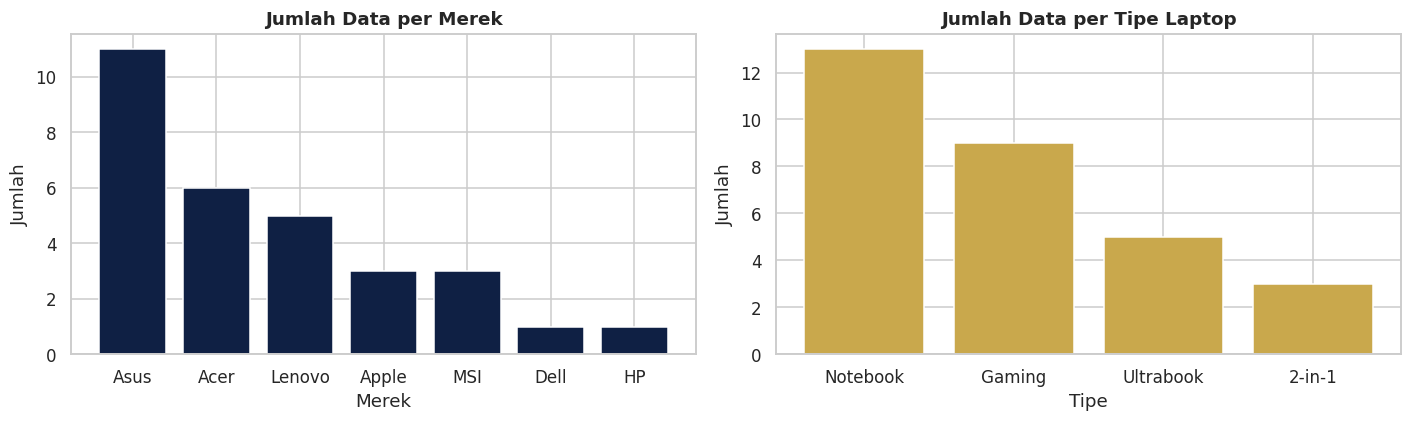

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(df_kecil["Merek (Company)"].value_counts().index,
            df_kecil["Merek (Company)"].value_counts().values,
            color="#0F2044", edgecolor="white")
axes[0].set_title("Jumlah Data per Merek", fontweight="bold")
axes[0].set_xlabel("Merek")
axes[0].set_ylabel("Jumlah")

axes[1].bar(df_kecil["Tipe Laptop (TypeName)"].value_counts().index,
            df_kecil["Tipe Laptop (TypeName)"].value_counts().values,
            color="#C9A84C", edgecolor="white")
axes[1].set_title("Jumlah Data per Tipe Laptop", fontweight="bold")
axes[1].set_xlabel("Tipe")
axes[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()

### 3.2 Preprocessing Data

In [40]:
df_k = df_kecil.copy()

fitur_num_k  = ["Ukuran Layar (Inches)", "Freq. CPU (GHz)", "RAM (GB)", "Berat (kg)"]
fitur_kat_k  = ["Merek (Company)", "Tipe Laptop (TypeName)",
                "Merek CPU (CPU_Company)", "Merek GPU (GPU_Company)", "OS (OpSys)"]
target_k     = "Harga (Rp)"

le2 = LabelEncoder()
for col in fitur_kat_k:
    df_k[col + "_enc"] = le2.fit_transform(df_k[col])

fitur_enc_k = fitur_num_k + [c + "_enc" for c in fitur_kat_k]

X_k = df_k[fitur_enc_k]
y_k = df_k[target_k]

print(f"Total fitur (parameter X): {len(fitur_enc_k)}")
print("Fitur:", fitur_enc_k)

Total fitur (parameter X): 9
Fitur: ['Ukuran Layar (Inches)', 'Freq. CPU (GHz)', 'RAM (GB)', 'Berat (kg)', 'Merek (Company)_enc', 'Tipe Laptop (TypeName)_enc', 'Merek CPU (CPU_Company)_enc', 'Merek GPU (GPU_Company)_enc', 'OS (OpSys)_enc']


### 3.3 Model Regresi Linear Berganda

In [41]:
model_kecil = LinearRegression()
model_kecil.fit(X_k, y_k)

y_k_pred = model_kecil.predict(X_k)

r2_k   = r2_score(y_k, y_k_pred)
mae_k  = mean_absolute_error(y_k, y_k_pred)
rmse_k = np.sqrt(mean_squared_error(y_k, y_k_pred))

print("=== HASIL EVALUASI MODEL (Dataset Kecil) ===")
print(f"R² Score  : {r2_k:.4f}  →  model menjelaskan {r2_k*100:.1f}% variasi harga")
print(f"MAE       : Rp {mae_k:,.0f}")
print(f"RMSE      : Rp {rmse_k:,.0f}")

=== HASIL EVALUASI MODEL (Dataset Kecil) ===
R² Score  : 0.9261  →  model menjelaskan 92.6% variasi harga
MAE       : Rp 2,095,794
RMSE      : Rp 2,647,230


In [42]:
koef_k = pd.DataFrame({
    "Parameter (X)": fitur_enc_k,
    "Koefisien"    : model_kecil.coef_
}).sort_values("Koefisien", ascending=False).reset_index(drop=True)

print(f"Intercept (a) : {model_kecil.intercept_:,.2f}")
print()
print("Koefisien tiap parameter:")
print(koef_k.to_string(index=False))

Intercept (a) : -107,384,507.85

Koefisien tiap parameter:
              Parameter (X)     Koefisien
             OS (OpSys)_enc  1.556326e+07
      Ukuran Layar (Inches)  1.313959e+07
Merek GPU (GPU_Company)_enc  7.106637e+06
                   RAM (GB)  4.669712e+05
            Freq. CPU (GHz)  4.414818e+05
        Merek (Company)_enc -1.717321e+05
 Tipe Laptop (TypeName)_enc -5.361764e+06
Merek CPU (CPU_Company)_enc -6.116977e+06
                 Berat (kg) -4.570128e+07


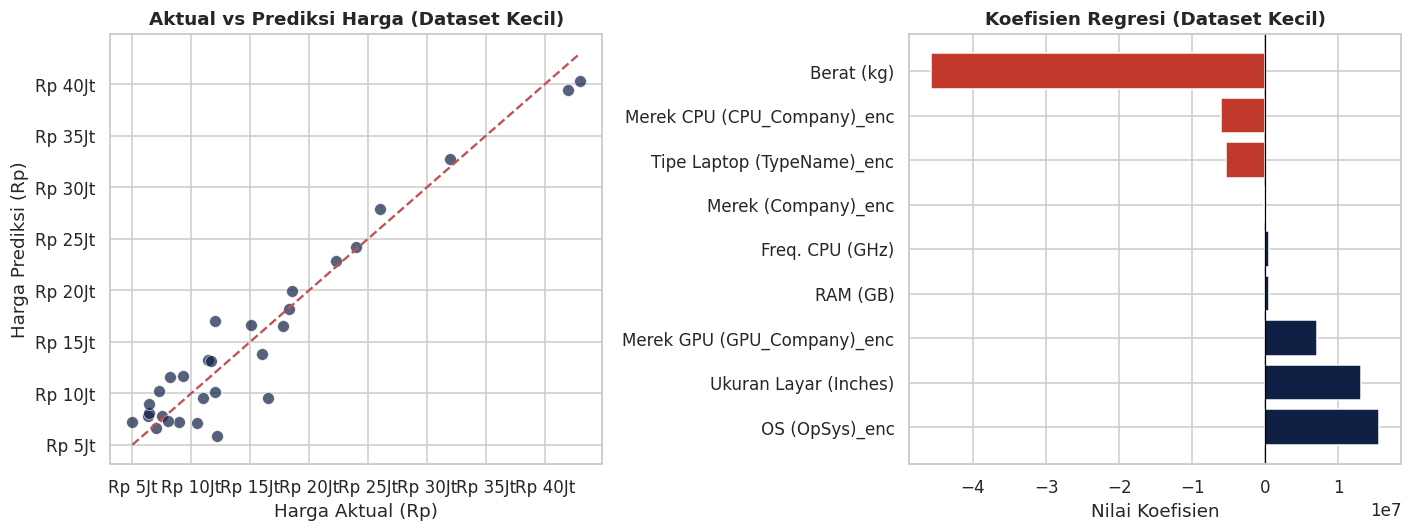

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_k, y_k_pred, alpha=0.7, color="#0F2044", s=60, edgecolors="white", linewidths=0.5)
axes[0].plot([y_k.min(), y_k.max()], [y_k.min(), y_k.max()], "r--", lw=1.5)
axes[0].set_title("Aktual vs Prediksi Harga (Dataset Kecil)", fontweight="bold")
axes[0].set_xlabel("Harga Aktual (Rp)")
axes[0].set_ylabel("Harga Prediksi (Rp)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x/1e6:.0f}Jt"))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp {x/1e6:.0f}Jt"))

colors_k = ["#0F2044" if c >= 0 else "#C0392B" for c in koef_k["Koefisien"]]
axes[1].barh(koef_k["Parameter (X)"], koef_k["Koefisien"], color=colors_k)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Koefisien Regresi (Dataset Kecil)", fontweight="bold")
axes[1].set_xlabel("Nilai Koefisien")

plt.tight_layout()
plt.show()

---
## 4. Perbandingan Hasil Kedua Model

In [44]:
print("=" * 50)
print("   PERBANDINGAN MODEL REGRESI LINEAR BERGANDA")
print("=" * 50)
print(f"{'Metrik':<12} {'Dataset Besar':>18} {'Dataset Kecil':>18}")
print("-" * 50)
print(f"{'R² Score':<12} {r2_b:>18.4f} {r2_k:>18.4f}")
print(f"{'Jml Data':<12} {len(df_besar):>18} {len(df_kecil):>18}")
print("=" * 50)
print()
if r2_b > r2_k:
    print(f"✅ Dataset besar menghasilkan model yang lebih baik (R²={r2_b:.4f})")
    print("   Karena jumlah data lebih banyak → pola lebih terbaca oleh model")
else:
    print(f"✅ Dataset kecil menghasilkan R² lebih tinggi (R²={r2_k:.4f})")
    print("   Kemungkinan karena data kecil lebih homogen")

   PERBANDINGAN MODEL REGRESI LINEAR BERGANDA
Metrik            Dataset Besar      Dataset Kecil
--------------------------------------------------
R² Score                 0.6697             0.9261
Jml Data                     30                 30

✅ Dataset kecil menghasilkan R² lebih tinggi (R²=0.9261)
   Kemungkinan karena data kecil lebih homogen


---
## 5. Kesimpulan

Berdasarkan analisis regresi linear berganda yang telah dilakukan:

1. **Model Dataset Besar (Kaggle)** menggunakan 1.275 data laptop dengan 9 parameter (fitur) menghasilkan model yang lebih stabil secara statistik.

2. **Model Dataset Kecil (Survey Mandiri)** menggunakan 30 data laptop terbaru dari Tokopedia/Shopee tahun 2025 sebagai validasi dan pembanding.

3. Parameter yang paling berpengaruh terhadap harga laptop dapat dilihat dari nilai koefisien regresi — semakin besar nilainya, semakin besar pengaruhnya terhadap harga.

4. Nilai **R²** menunjukkan seberapa besar variasi harga yang dapat dijelaskan oleh model regresi yang dibuat.

